In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

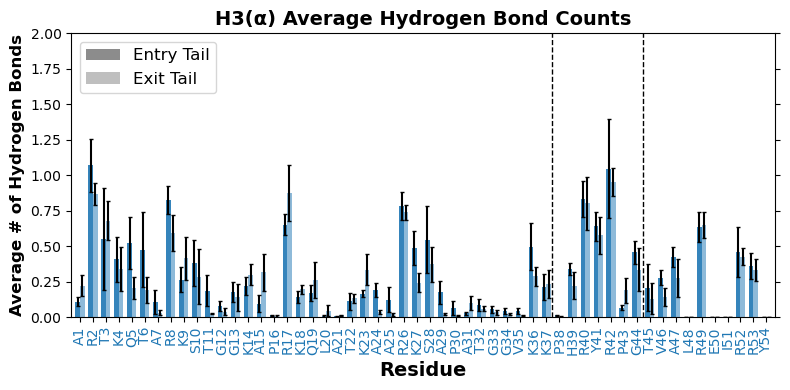

In [7]:
# Read data
def read_data(file_path):
    data = []
    with open(file_path, 'r') as file:
        for line in file:
            _, average = line.strip().split(': ')
            data.append(float(average))
    return data

# Directory paths
run_dirs = ['run1', 'run2', 'run3', 'run4']

# Read data from each run
data_runs = []

for run_dir in run_dirs:
    output_file_1 = os.path.join(run_dir, 'entry_avgs.dat')
    output_file_2 = os.path.join(run_dir, 'exit_avgs.dat')

    # REMOVE last two residues
    data_1 = read_data(output_file_1)[:-2]
    data_2 = read_data(output_file_2)[:-2]

    data_runs.append(np.column_stack((data_1, data_2)))

# Residue labels
codes = [
    'A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
    'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
    'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
    'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
    'Y41','R42','P43','G44','T45','V46','A47','L48','R49','E50',
    'I51','R52','R53','Y54'
]

# Statistics
averages = np.mean(data_runs, axis=0)
std_errors = np.std(data_runs, axis=0) / np.sqrt(len(run_dirs))

# Region-specific colors
highlight_colors = {}

# Tail region (0–36)
for i in range(0, 37):
    highlight_colors[i] = "tab:blue"

# Latch region (37–43)
for i in range(37, 44):
    highlight_colors[i] = "tab:blue"

# AlphaN region (44–51)
for i in range(44, 54):
    highlight_colors[i] = "tab:blue"

# Plotting
fig, ax = plt.subplots(figsize=(8, 4))

bar_width = 0.35
index = np.arange(len(codes))

# Data bars
for i in range(len(codes)):

    color = highlight_colors[i]

    # Entry
    ax.bar(index[i], averages[i, 0], bar_width, alpha=0.9, color=color)

    # Exit
    ax.bar(index[i] + bar_width, averages[i, 1], bar_width, alpha=0.5, color=color)

# Error bars
ax.errorbar(index, averages[:, 0], yerr=std_errors[:, 0], fmt='none', capsize=1.5, color='black')

ax.errorbar(index + bar_width, averages[:, 1], yerr=std_errors[:, 1], fmt='none', capsize=1.5, color='black')

# Region separators
ax.axvline(x=36.65, linestyle='--', color='black', linewidth=1)

ax.axvline(x=43.65, linestyle='--', color='black', linewidth=1)

# Labels/titles
ax.set_xlabel('Residue', fontsize=14, fontweight='bold')
ax.set_ylabel('Average # of Hydrogen Bonds', fontsize=12, fontweight='bold')
ax.set_title('H3(\u03B1) Average Hydrogen Bond Counts', fontsize=14, fontweight='bold')

ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(codes, rotation='vertical')

# COLOR residue labels
for lbl, i in zip(ax.get_xticklabels(), range(len(codes))):
    lbl.set_color(highlight_colors[i])

ax.yaxis.set_ticks_position('both')

# Legend
entry_patch = plt.Rectangle((0,0),1,1,fc='gray',alpha=0.9)
exit_patch = plt.Rectangle((0,0),1,1,fc='gray',alpha=0.5)

ax.legend(
    [entry_patch, exit_patch],
    ['Entry Tail', 'Exit Tail'],
    fontsize=12
)

# Axis limits
plt.ylim(0, 2)

# REMOVE whitespace at ends
ax.set_xlim(-0.5, len(codes) - 0.5 + bar_width)

# Finalize
plt.tight_layout()

plt.savefig('ASAT_H3_hbond_counts.pdf')
plt.show()